# 04 - Error Analysis

This notebook performs detailed error analysis on NER model predictions.

**Objectives:**
- Load model predictions and gold labels
- Build confusion matrices per entity type
- Identify common FP/FN patterns
- Case studies of difficult queries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

DATA_DIR = Path('../data/annotations')
RESULTS_DIR = Path('../results/benchmark')
print('Setup complete!')

Setup complete!


## 1. Load Test Data and Predictions

In [2]:
test_df = pd.read_parquet(DATA_DIR / 'test.parquet')
print(f'Test samples: {len(test_df):,}')

gold_tags = test_df['ner_tags'].tolist()
print(f'Sample: {gold_tags[0]}')

Test samples: 11,250
Sample: ['O' 'B-PRODUCT_TYPE' 'B-PRODUCT_TYPE']


In [3]:
predictions = {}
for f in RESULTS_DIR.glob('*_predictions.json'):
    model = f.stem.replace('_predictions', '')
    with open(f) as fp:
        predictions[model] = json.load(fp)
    print(f'Loaded predictions: {model}')

if not predictions:
    print('No prediction files found. Run benchmark.py first.')

Loaded predictions: cnn_bilstm
Loaded predictions: bilstm_crf
Loaded predictions: bert_ner
Loaded predictions: roberta_ner


## 2. Confusion Matrix

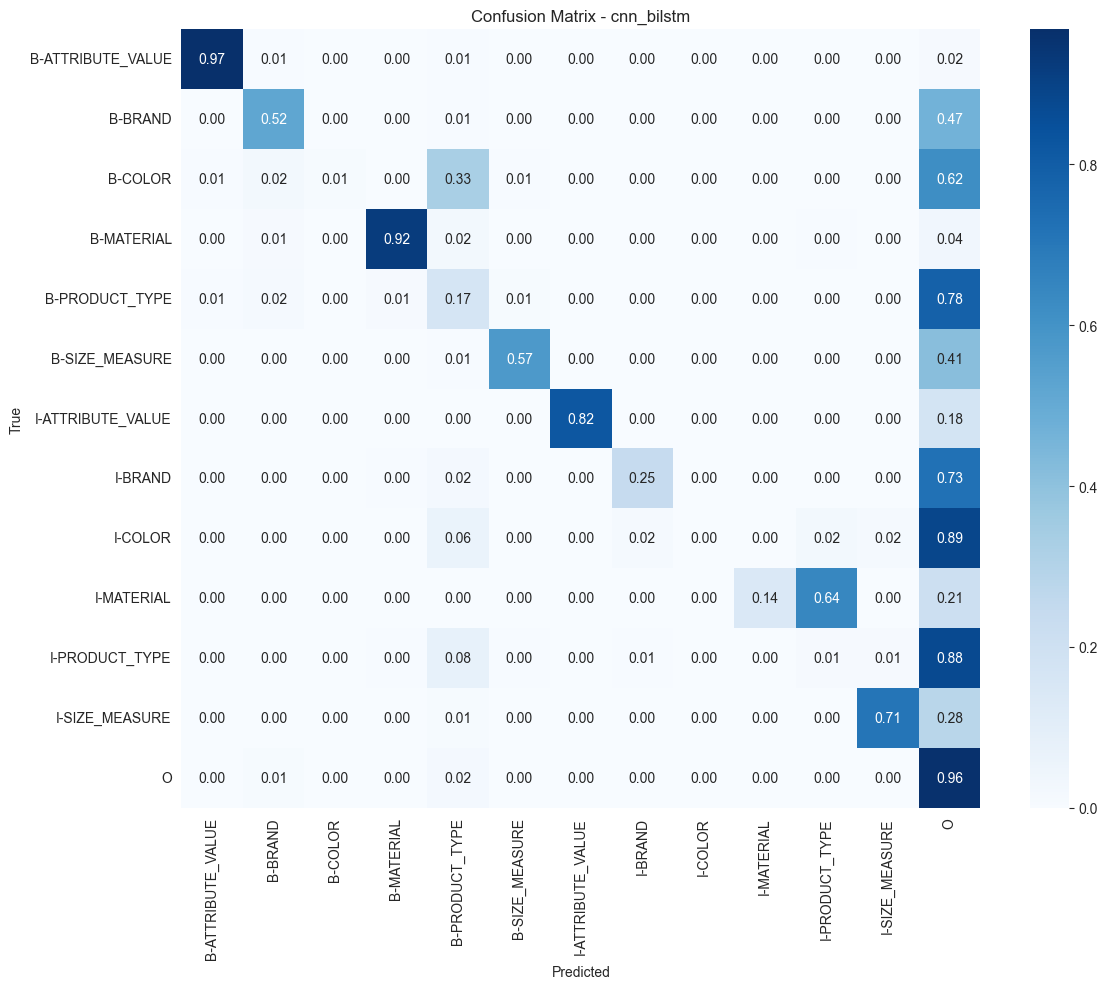

In [4]:
if predictions:
    model_name = list(predictions.keys())[0]
    pred_tags = predictions[model_name]
    
    # Flatten tags
    gold_flat = [t for tags in gold_tags for t in tags]
    pred_flat = [t for tags in pred_tags for t in tags]
    
    # Ensure same length
    min_len = min(len(gold_flat), len(pred_flat))
    gold_flat = gold_flat[:min_len]
    pred_flat = pred_flat[:min_len]
    
    labels = sorted(set(gold_flat + pred_flat))
    cm = confusion_matrix(gold_flat, pred_flat, labels=labels, normalize='true')
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_confusion.png', dpi=150)
    plt.show()

## 3. Error Type Analysis

In [5]:
if predictions:
    errors = defaultdict(int)
    for g, p in zip(gold_flat, pred_flat):
        if g != p:
            if g == 'O' and p != 'O':
                errors['False Positive (O→Entity)'] += 1
            elif g != 'O' and p == 'O':
                errors['False Negative (Entity→O)'] += 1
            elif g != 'O' and p != 'O':
                errors['Wrong Entity Type'] += 1
    
    print('Error Types:')
    for error_type, count in sorted(errors.items(), key=lambda x: -x[1]):
        print(f'  {error_type}: {count:,}')

Error Types:
  False Negative (Entity→O): 10,001
  False Positive (O→Entity): 1,044
  Wrong Entity Type: 887


## 4. Sample Errors

In [6]:
if predictions:
    model_name = list(predictions.keys())[0]
    pred_tags = predictions[model_name]
    
    print(f'Sample Errors ({model_name}):')
    print('=' * 60)
    
    error_count = 0
    for i, (row, preds) in enumerate(zip(test_df.itertuples(), pred_tags)):
        gold = list(row.ner_tags)
        if gold != preds and error_count < 10:
            tokens = list(row.query_tokens)
            print(f'Query: {row.query}')
            print(f'Tokens: {tokens}')
            print(f'Gold:   {gold}')
            print(f'Pred:   {preds}')
            print('-' * 60)
            error_count += 1

Sample Errors (cnn_bilstm):
Query: basketball shoes kids
Tokens: ['basketball', 'shoes', 'kids']
Gold:   ['O', 'B-PRODUCT_TYPE', 'B-PRODUCT_TYPE']
Pred:   ['O', 'O', 'O']
------------------------------------------------------------
Query: bape hoodie kids
Tokens: ['bape', 'hoodie', 'kids']
Gold:   ['O', 'O', 'B-PRODUCT_TYPE']
Pred:   ['O', 'O', 'O']
------------------------------------------------------------
Query: micro sd card 1tb
Tokens: ['micro', 'sd', 'card', '1tb']
Gold:   ['O', 'O', 'B-PRODUCT_TYPE', 'O']
Pred:   ['O', 'O', 'O', 'O']
------------------------------------------------------------
Query: mestar iron pro
Tokens: ['mestar', 'iron', 'pro']
Gold:   ['B-BRAND', 'B-MATERIAL', 'O']
Pred:   ['O', 'B-MATERIAL', 'O']
------------------------------------------------------------
Query: puzzle 200 pieces
Tokens: ['puzzle', '200', 'pieces']
Gold:   ['O', 'B-SIZE_MEASURE', 'I-SIZE_MEASURE']
Pred:   ['B-PRODUCT_TYPE', 'B-SIZE_MEASURE', 'I-SIZE_MEASURE']
---------------------------

## 5. Summary

In [7]:
print('=' * 50)
print('ERROR ANALYSIS SUMMARY')
print('=' * 50)
print(f'Test samples: {len(test_df):,}')
print(f'Models analyzed: {len(predictions)}')
if predictions and errors:
    total_errors = sum(errors.values())
    print(f'Total errors: {total_errors:,}')
    print(f'Error rate: {total_errors/len(gold_flat)*100:.2f}%')

ERROR ANALYSIS SUMMARY
Test samples: 11,250
Models analyzed: 4
Total errors: 11,932
Error rate: 28.87%
